In [1]:
# Import required libraries for dataset handling and data manipulation
from datasets import load_dataset_builder , load_dataset
import pandas as pd
import matplotlib.pyplot as plt


# Load the dataset builder to inspect metadata without downloading the full dataset
ds_builder = load_dataset_builder("openlifescienceai/medmcqa")

In [2]:
# Display the dataset description to understand its purpose and content
# (empty string here - this dataset card has no description field filled in)
ds_builder.info.description

''

In [3]:
# Display the dataset features/schema to understand column names and data types
# question + opa/opb/opc/opd are the 4 choices, cop is the correct-option index
ds_builder.info.features

{'id': Value('string'),
 'question': Value('string'),
 'opa': Value('string'),
 'opb': Value('string'),
 'opc': Value('string'),
 'opd': Value('string'),
 'cop': ClassLabel(names=['a', 'b', 'c', 'd']),
 'choice_type': Value('string'),
 'exp': Value('string'),
 'subject_name': Value('string'),
 'topic_name': Value('string')}

In [4]:
# Load the complete medmcqa dataset (train, test, and validation splits)
# First run downloads and caches locally; later runs read from the cache
ds = load_dataset("openlifescienceai/medmcqa")

In [5]:
# Inspect the first sample from the training dataset to understand data structure
# Note: cop is a 0-based integer (2 -> option 'c'), and exp holds the rationale text
ds['train'][0]

{'id': 'e9ad821a-c438-4965-9f77-760819dfa155',
 'question': 'Chronic urethral obstruction due to benign prismatic hyperplasia can lead to the following change in kidney parenchyma',
 'opa': 'Hyperplasia',
 'opb': 'Hyperophy',
 'opc': 'Atrophy',
 'opd': 'Dyplasia',
 'cop': 2,
 'choice_type': 'single',
 'exp': 'Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnancy, tumors, uterine prolapse or functional disorders cause hydronephrosis which by definition is used to describe dilatation of renal pelvis and calculus associated with progressive atrophy of the kidney due to obstruction to the outflow of urine Refer Robbins 7yh/9,1012,9/e. P950',
 'subject_name': 'Anatomy',
 'topic_name': 'Urinary tract'}

In [6]:
# Convert dataset splits to pandas DataFrames for easier data manipulation and analysis
df_train = ds['train'].to_pandas()
df_test = ds['test'].to_pandas()
df_validate = ds['validation'].to_pandas()

In [7]:
# Display the first 10 rows of the training dataset to inspect the data
# Watch for NaN in topic_name and exp - both are sparsely populated
df_train.head(10)

,id,question,opa,opb,opc,opd,cop,choice_type,exp,subject_name,topic_name
0,e9ad821a-c438-4965-9f77-760819dfa155,Chronic urethral obstruction due to benign pri...,Hyperplasia,Hyperophy,Atrophy,Dyplasia,2,single,Chronic urethral obstruction because of urinar...,Anatomy,Urinary tract
1,e3d3c4e1-4fb2-45e7-9f88-247cc8f373b3,Which vitamin is supplied from only animal sou...,Vitamin C,Vitamin B7,Vitamin B12,Vitamin D,2,single,Ans. (c) Vitamin B12 Ref: Harrison's 19th ed. ...,Biochemistry,Vitamins and Minerals
2,5c38bea6-787a-44a9-b2df-88f4218ab914,All of the following are surgical options for ...,Adjustable gastric banding,Biliopancreatic diversion,Duodenal Switch,Roux en Y Duodenal By pass,3,multi,"Ans. is 'd' i.e., Roux en Y Duodenal Bypass Ba...",Surgery,Surgical Treatment Obesity
3,cdeedb04-fbe9-432c-937c-d53ac24475de,Following endaerectomy on the right common car...,Central aery of the retina,Infraorbital aery,Lacrimal aery,Nasociliary aretry,0,multi,The central aery of the retina is a branch of ...,Ophthalmology,NaN
4,dc6794a3-b108-47c5-8b1b-3b4931577249,Growth hormone has its effect on growth through?,Directly,IG1-1,Thyroxine,Intranuclear receptors,1,single,"Ans. is 'b' i.e., IGI-1GH has two major functi...",Physiology,NaN
5,5ab84ea8-12d1-47d4-ab22-668ebf01e64c,Scrub typhus is transmitted by: September 2004,Louse,Tick,Mite,Milk,2,single,Ans. C i.e. Mite,Social & Preventive Medicine,NaN
6,a83de6e4-9427-4480-b404-d96621ebb640,Abnormal vascular patterns seen with colposcop...,Punctation,Mosaicism,Satellite lesions,Atypical vessels,2,multi,"Abnormal vascular pattern include punctation, ...",Gynaecology & Obstetrics,NaN
7,f3bf8583-231b-4b7a-828c-179b0f9ccdd9,Per rectum examination is not a useful test fo...,Anal fissure,Hemorrhoid,Pilonidal sinus,Rectal ulcer,2,single,PILONIDAL SINUS/DISEASE (Jeep Bottom; Driver's...,Surgery,Urology
8,73515f05-e947-4801-8077-3abdeca95c84,Characteristics of Remifentanyl – a) Metabolis...,ab,bc,abc,bcd,2,single,Remifentanil is the shortest acting opioid due...,Anaesthesia,NaN
9,53f79833-21b0-4336-8ef4-404c687ec807,Hypomimia is ?,Decreased ability to copy,Decreased execution,Deficit of expression by gesture,Deficit of fluent speech,2,single,Ans. C. Deficit of expression by gestureHypomi...,Psychiatry,NaN


In [8]:
# Filter training data where choice_type equals 'multi' and display first 10 rows
# Despite the label, cop is still a single index - the question text is what's multi-part
df_train[df_train['choice_type'] == 'multi'].head(10)

,id,question,opa,opb,opc,opd,cop,choice_type,exp,subject_name,topic_name
2,5c38bea6-787a-44a9-b2df-88f4218ab914,All of the following are surgical options for ...,Adjustable gastric banding,Biliopancreatic diversion,Duodenal Switch,Roux en Y Duodenal By pass,3,multi,"Ans. is 'd' i.e., Roux en Y Duodenal Bypass Ba...",Surgery,Surgical Treatment Obesity
3,cdeedb04-fbe9-432c-937c-d53ac24475de,Following endaerectomy on the right common car...,Central aery of the retina,Infraorbital aery,Lacrimal aery,Nasociliary aretry,0,multi,The central aery of the retina is a branch of ...,Ophthalmology,NaN
6,a83de6e4-9427-4480-b404-d96621ebb640,Abnormal vascular patterns seen with colposcop...,Punctation,Mosaicism,Satellite lesions,Atypical vessels,2,multi,"Abnormal vascular pattern include punctation, ...",Gynaecology & Obstetrics,NaN
11,e529be7c-f360-4dba-b313-7f3fc240697a,Which of the following statements are True/Fal...,"1, 2, 3 True & 4, 5 false","1, 3, 5 True & 2, 4 false","2, 4, 5 True & 1, 3 false","1, 2, 3, 4 True & 5 false",2,multi,Here statement 1 & 3 are wrong. It is actually...,Medicine,NaN
13,d64eabcf-da66-438f-a53f-7137d3bba9dd,True regarding lag phase is?,Time taken to adpt in the new environment,Growth occurs exponentially,The plateau in lag phase is due to cell death,It is the 2nd phase in bacterial growth curve,0,multi,Lag phase: Immediately following the seeding o...,Microbiology,general microbiology
17,b1a4e1b8-fb3d-40e4-9da7-ebc8a9c0963b,For a positively skewed curve which measure of...,Mean,Mode,Median,All are equal,0,multi,"A distribution is negatively skewed, or skewed...",Social & Preventive Medicine,Biostatistics
20,9ecbc05b-b255-47b5-b7b1-bf55f0f21abd,Testicular artery usually arises from,Abdominal aorta below renal artery,Renal artery,Internal iliac artery,Ext iliac artery,0,multi,Ans) a (Abdominal aorta ....) Ref Chaurasia vo...,Surgery,Testis & Scrotum
22,e9038cb9-56db-473d-9d3f-440f130295ec,Organisms that has not been cultured successfu...,Leptospira,Treponema pallidum,Bordetella,Staphylococcus,1,multi,NaN,Microbiology,NaN
30,e7f60d58-db4c-4067-981b-2988a9de88ff,Risk factors associated with post-operative na...,Age < 3years,Duration of anesthesia > 30 mins,Personal or family history of post - op nausea...,Personal or family history of motion sickness,0,multi,"Ans. is 'a' i.e., Age < 3 years Post operative...",Anaesthesia,NaN
31,7f11c629-b766-486f-a98e-6de0a2be8ae3,All are True about Acute Osteomyelitis except,Common in children,Severe pain,Involves Epiphyseal plate,Treatment involves 6 weeks of Antibiotics,2,multi,NaN,Orthopaedics,NaN


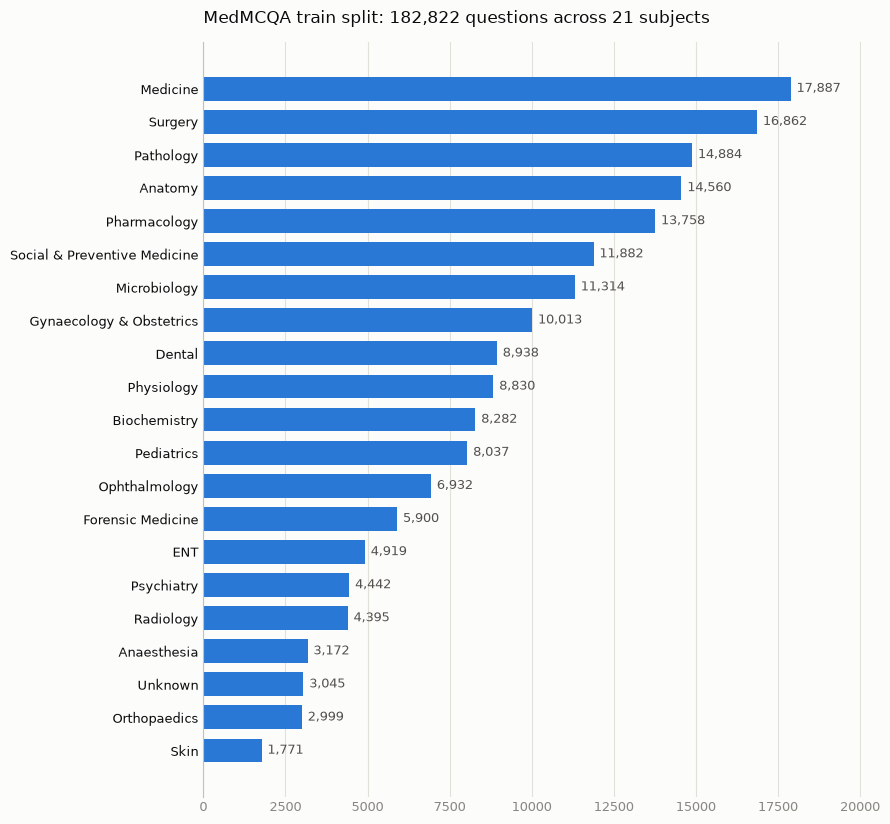

In [9]:
# Distribution of questions across medical subjects in the training split

# Count questions per subject; ascending sort puts the largest bar at the top
subject_counts = df_train['subject_name'].value_counts().sort_values()

# Figure height grows with the subject count so bars keep a fixed thickness
fig, ax = plt.subplots(figsize=(9, 0.34 * len(subject_counts) + 1.2))
fig.patch.set_facecolor('#fcfcfb')
ax.set_facecolor('#fcfcfb')

# Horizontal bars - subject names are long and read better on the y-axis
ax.barh(subject_counts.index, subject_counts.values, color='#2a78d6', height=0.72)

# Print the exact count just past the end of each bar
for name, value in subject_counts.items():
    ax.text(value + subject_counts.max() * 0.01, name, f'{value:,}',
            va='center', fontsize=9, color='#52514e')

# Pad the x-axis so those value labels aren't clipped at the right edge
ax.set_xlim(0, subject_counts.max() * 1.12)
ax.set_title(f'MedMCQA train split: {len(df_train):,} questions across '
             f'{len(subject_counts)} subjects', fontsize=12, color='#0b0b0b', pad=14, loc='left')

# Faint vertical gridlines, drawn behind the bars
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

# Strip tick marks and the chart frame, keeping only the left spine
ax.tick_params(axis='y', length=0, labelsize=9, colors='#0b0b0b')
ax.tick_params(axis='x', length=0, labelsize=9, colors='#898781')
for side in ('top', 'right', 'bottom'):
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color('#c3c2b7')

plt.tight_layout()
plt.show()

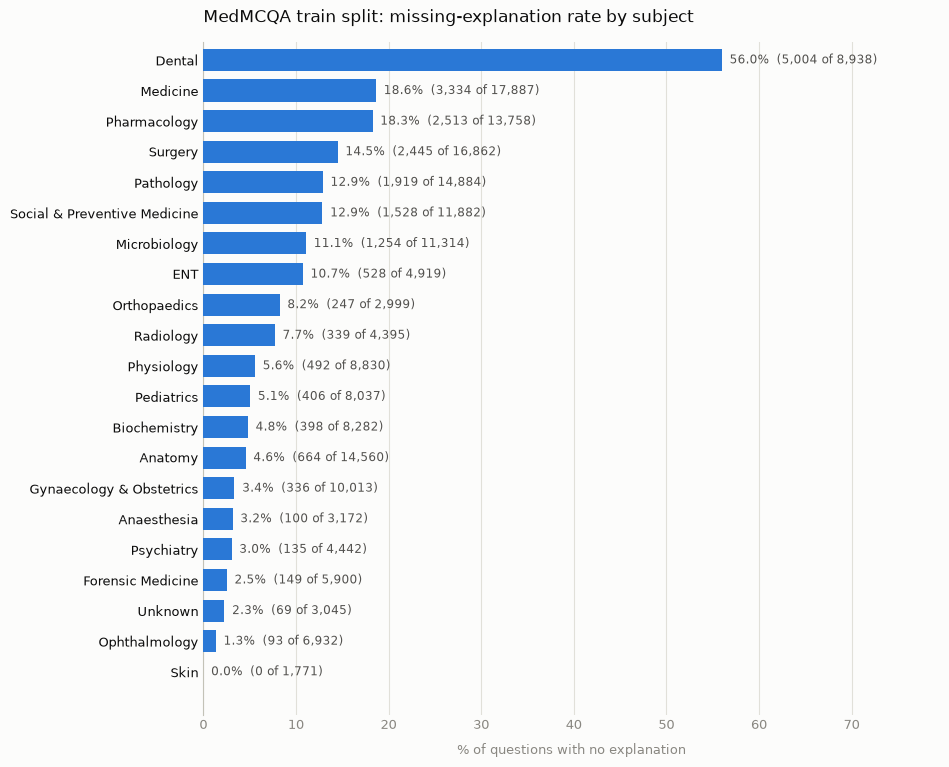

In [10]:
# How often the 'exp' rationale is missing, broken down by subject
# Matters for SFT: questions with no explanation can't be used for reasoning-style targets

# Shared palette constants reused across the chart
SURFACE, INK, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#898781', '#e1e0d9', '#c3c2b7'

# Treat NaN and whitespace-only strings as missing
missing = df_train['exp'].fillna('').str.strip() == ''

# Per subject: how many are missing, and how many questions in total
by_subject = (df_train.assign(exp_missing=missing)
              .groupby('subject_name')['exp_missing']
              .agg(missing_n='sum', total='size'))

# Rate rather than raw count, so small and large subjects stay comparable
by_subject['pct'] = by_subject['missing_n'] / by_subject['total'] * 100
by_subject = by_subject.sort_values('pct')

# overall = missing.mean() * 100

# Figure height grows with the subject count so bars keep a fixed thickness
fig, ax = plt.subplots(figsize=(9.5, 0.34 * len(by_subject) + 1.6))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

# zorder=3 keeps the bars above the gridlines
ax.barh(by_subject.index, by_subject['pct'], color='#2a78d6', height=0.72, zorder=3)

# Annotate each bar with the percentage and the underlying counts
for name, row in by_subject.iterrows():
    ax.text(row['pct'] + by_subject['pct'].max() * 0.015, name,
            f"{row['pct']:.1f}%  ({int(row['missing_n']):,} of {int(row['total']):,})",
            va='center', fontsize=8.5, color='#52514e')

# Wide right margin for the long labels; extra y-room below the first bar
ax.set_xlim(0, by_subject['pct'].max() * 1.42)
ax.set_ylim(-1.4, len(by_subject) - 0.4)
ax.set_xlabel('% of questions with no explanation', fontsize=9, color=MUTED, labelpad=8)
ax.set_title('MedMCQA train split: missing-explanation rate by subject',
             fontsize=12, color=INK, pad=14, loc='left')

# Faint vertical gridlines, drawn behind the bars
ax.xaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

# Strip tick marks and the chart frame, keeping only the left spine
ax.tick_params(axis='y', length=0, labelsize=9, colors=INK)
ax.tick_params(axis='x', length=0, labelsize=9, colors=MUTED)
for side in ('top', 'right', 'bottom'):
    ax.spines[side].set_visible(False)
ax.spines['left'].set_color(AXIS)

plt.show()

# Uncomment for the numeric table and the overall missing rate
# print(by_subject.sort_values('pct', ascending=False).to_string())
# print(f"\noverall {overall:.2f}%  total missing {int(by_subject['missing_n'].sum()):,}")

